In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage

In [2]:

load_dotenv()


True

In [3]:
model=ChatOpenAI(model='gpt-4o-mini')

In [4]:

def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:

builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [7]:

graph = builder.compile(checkpointer=InMemorySaver())

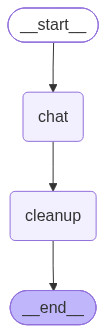

In [8]:
graph

In [9]:

config = {"configurable": {"thread_id": "t1"}}


In [12]:

# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Samrat"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='Now explain checkpointers', additional_kwargs={}, response_metadata={}, id='960e305b-c72c-401d-ab30-35479403dae1'),
  AIMessage(content='"Checkpointers" typically refer to the mechanisms or systems used to save the state of a process or application at a specific point in time. This concept is often applied in various computing fields, including databases, distributed systems, machine learning, and game development. The term might not refer to a single standard definition, but here’s an overview of how "checkpoints" (as they are often called) are generally understood in different contexts.\n\n### General Concept of Checkpoints\n\n1. **State Saving**: A checkpoint captures the state of an application or system at a particular moment. This can include in-memory data, configurations, execution states, etc.\n\n2. **Fault Tolerance**: One of the primary uses of checkpoints is to provide resilience against failures. If a system crashes or experiences an err

In [11]:

snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
